<a href="https://colab.research.google.com/github/AadhiX458/24BAD003_ML-EXP-3/blob/main/MPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving auto-mpg.csv to auto-mpg.csv


{'auto-mpg.csv': b"mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name\r\n18,8,307,130,3504,12,70,1,chevrolet chevelle malibu\r\n15,8,350,165,3693,11.5,70,1,buick skylark 320\r\n18,8,318,150,3436,11,70,1,plymouth satellite\r\n16,8,304,150,3433,12,70,1,amc rebel sst\r\n17,8,302,140,3449,10.5,70,1,ford torino\r\n15,8,429,198,4341,10,70,1,ford galaxie 500\r\n14,8,454,220,4354,9,70,1,chevrolet impala\r\n14,8,440,215,4312,8.5,70,1,plymouth fury iii\r\n14,8,455,225,4425,10,70,1,pontiac catalina\r\n15,8,390,190,3850,8.5,70,1,amc ambassador dpl\r\n15,8,383,170,3563,10,70,1,dodge challenger se\r\n14,8,340,160,3609,8,70,1,plymouth 'cuda 340\r\n15,8,400,150,3761,9.5,70,1,chevrolet monte carlo\r\n14,8,455,225,3086,10,70,1,buick estate wagon (sw)\r\n24,4,113,95,2372,15,70,3,toyota corona mark ii\r\n22,6,198,95,2833,15.5,70,1,plymouth duster\r\n18,6,199,97,2774,15.5,70,1,amc hornet\r\n21,6,200,85,2587,16,70,1,ford maverick\r\n27,4,97,88,2130,14.5,70,3,datsun pl510\r\

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_csv("auto-mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [6]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [7]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [9]:
features= df[['horsepower', 'mpg']]

In [10]:
features['horsepower'] = features['horsepower'].replace('?', np.nan)
features['horsepower'] = pd.to_numeric(features['horsepower'])


/tmp/ipykernel_173/2431739229.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['horsepower'] = features['horsepower'].replace('?', np.nan)
/tmp/ipykernel_173/2431739229.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['horsepower'] = pd.to_numeric(features['horsepower'])


In [11]:
features.dropna(inplace=True)

/tmp/ipykernel_173/962423859.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.dropna(inplace=True)


In [12]:
X = features[['horsepower']]
y = features['mpg']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
degrees = [2, 3, 4]

In [16]:

for d in degrees:
    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)





In [17]:
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

MSE : 18.268226869623437
RMSE: 4.274134634007618
R2  : 0.6420842845041201


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


NameError: name 'sns' is not defined

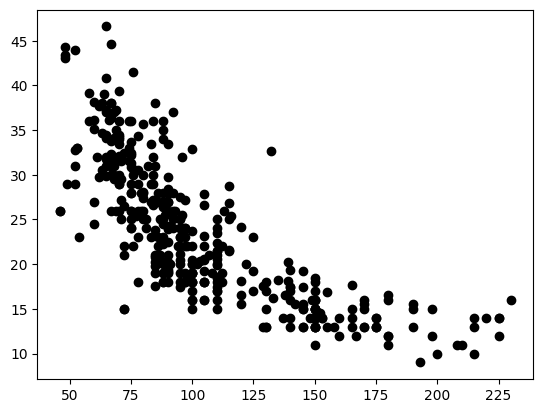

In [18]:
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range = scaler.transform(X_range)

plt.scatter(features['horsepower'], features['mpg'], color='black')

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_train), y_train)

    y_curve = model.predict(poly.transform(X_range))
    sns.lineplot(X_range, y_curve)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.show()

In [19]:
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

y_pred_ridge = ridge.predict(X_test_poly)

print("Ridge Regression")
print("MSE :", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2  :", r2_score(y_test, y_pred_ridge))

Ridge Regression
MSE : 18.265005901296124
RMSE: 4.273757819682361
R2  : 0.6421473905292252


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.76945e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
